# 🛒 Online Shopping A/B Testing: Statistical Analysis & Business Impact

---

 **📌 Project Overview** This project evaluates the effectiveness of three key e-commerce features: a **New Recommendation System**, a **Button Color Change**, and multiple **Marketing Campaigns**. By implementing a robust Statistical Hypothesis Testing pipeline, the goal is to distinguish genuine business improvements from random variance and accurately estimate their impact on sales and conversion rates.

---

 **📊 Summary**

**1. Recommendation System Impact (Algorithm A/B Test)** 
- **Goal:** Determine if the new algorithm increases the number of items added to the cart.
- **Insight:** Because the data is not normally distributed, the **Brunner-Munzel test** was used instead of a standard T-test. 
- **Business Value:** Alongside the p-value, **Bootstrap Confidence Intervals** were applied to estimate the actual monetary impact (per person) the new algorithm brings to total sales.

**2. UI/UX Optimization (Button Color)** 
- **Goal:** Analyze whether changing the button color significantly impacts user conversion rates.
- **Insight**: Used a **Z-Test** to compare conversion rates and checked **Cohen's** h to make sure the difference was big enough to actually be useful for the business, not just a result of random luck.

**3. Marketing Campaign Effectiveness (A/B/n Testing)** 
- **Goal:** Compare the success rates across multiple promotional campaigns.
- **Insight:** Evaluated overall variance using a **Chi-Square Test** and **Cramer's V / Cohen's W** for effect size. 
- **Findings:** Compared campaigns side-by-side to find the clear winners, making sure the results are highly accurate and not due to chance.

---

 **🛠 Technical Highlights**
* **Statistical Rigor & Power Analysis:** Implemented robust power analysis (`statsmodels`, `pingouin`) across all tests to prevent Type II errors and ensure sample sizes were large enough to detect meaningful effects.
* **Distribution-Aware Testing:** Automated normality checks (`pg.normality`) to intelligently route data to either parametric (T-Test) or non-parametric (Brunner-Munzel) statistical tests.
* **Effect Size Over P-Values:** Prioritized measuring the magnitude of changes (Cohen’s d, h, w, and Cramer’s V) to answer "How much does this matter?" rather than just "Is there a difference?".
* **Advanced Error Control:** Utilized `itertools.combinations` and `multipletests` for post-hoc analysis, strictly adjusting alpha thresholds to maintain integrity when running multiple comparisons.

---

 **💻 Tech Stack**
* **Data Manipulation:** `Pandas`, `NumPy`
* **Statistical Testing:** `SciPy` (Brunner-Munzel, Bootstrap), `Statsmodels` (Z-test, Multiple Comparisons)
* **Advanced Analytics:** `Pingouin` (Power Analysis, Normality, Effect Size)
* **Data Visualization:** `Matplotlib`, `Seaborn` (Visualized with `ggplot` style and `Set2` palette)
* **Workflow & Utilities:** `Kagglehub` (Data Sourcing), `Itertools` (Pairwise Combinations)

---

 **📚 Data Source**
- **Dataset:** Online Shopping Hypothesis Testing
- **Source:** [Kaggle - sakdaphoda/online-shopping-hypothesis-testing](https://www.kaggle.com/datasets/sakdaphoda/online-shopping-hypothesis-testing)

# Setup Env

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter as kda
import pingouin as pg
import itertools

from scipy.stats import brunnermunzel, bootstrap, chi2_contingency
from scipy.stats.contingency import association
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower, GofChisquarePower
from statsmodels.sandbox.stats.multicomp import multipletests
from IPython.display import display

# Set plot style
plt.style.use('ggplot')
sns.set_palette('Set2')


# Load Data

In [30]:
df_button = kagglehub.dataset_load(kda.PANDAS, 'sakdaphoda/online-shopping-hypothesis-testing','dataset1_button_color.csv')
df_campaign = kagglehub.dataset_load(kda.PANDAS, 'sakdaphoda/online-shopping-hypothesis-testing','dataset2_campaign_promo.csv')
df_reco = kagglehub.dataset_load(kda.PANDAS, 'sakdaphoda/online-shopping-hypothesis-testing','dataset3_reco_system.csv')


# 1. New Recommendation System Testing

## 1.1 Overview Checking

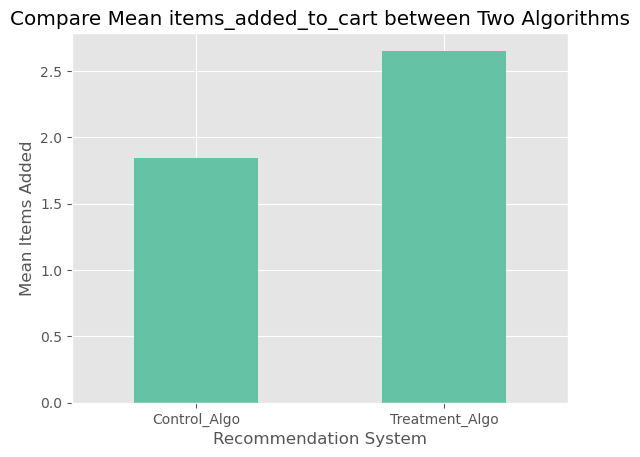

In [31]:
mean_item = df_reco.groupby('reco_system')['items_added_to_cart'].mean()
mean_item.plot.bar(rot=0)
plt.title('Compare Mean items_added_to_cart between Two Algorithms')
plt.ylabel('Mean Items Added')
plt.xlabel('Recommendation System')
plt.show()


## 1.2 Check Power and Effect Size

In [32]:
control_algo = df_reco[df_reco['reco_system'] == 'Control_Algo']['items_added_to_cart']
treatment_algo = df_reco[df_reco['reco_system'] == 'Treatment_Algo']['items_added_to_cart']

n_control_algo = len(control_algo)
n_treatment_algo = len(treatment_algo)

# Check Power and Effect Size 
cohens_d = pg.compute_effsize(control_algo, treatment_algo, eftype='cohen')
power = pg.power_ttest2n(
    nx=n_control_algo, 
    ny=n_treatment_algo, 
    d=cohens_d, 
    alpha=0.05, 
    alternative='less'
)

print(f"Size: Control Algorithm ({n_control_algo}) , Treatment Algorithm ({n_treatment_algo})")
print(f"Effect Size (Cohen's d): {cohens_d:.4f}")

if cohens_d >= 0.8:
    print("    -> Large Effect")
elif cohens_d >= 0.5:
    print("    -> Medium Effect")
else: 
    print("    -> Small Effect")

print(f"Achieved Power: {power:.4f}")
if power < 0.8:
    print('    -> Sample size might be too small. Risk of Type II Error.')
    required_n = pg.power_ttest(
        power=0.8, 
        d=cohens_d, 
        alpha=0.05, 
        alternative='less'
    )
    required_n = np.ceil(required_n).astype(int)
    
    print(f"    -> Advice: To achieve a Power of 0.8, you need about {required_n} samples per group (Total: {required_n * 2}).")
else:
    print('    -> Good statistical power (Reliable data size)')


Size: Control Algorithm (764) , Treatment Algorithm (736)
Effect Size (Cohen's d): -0.5605
    -> Small Effect
Achieved Power: 1.0000
    -> Good statistical power (Reliable data size)


## 1.3 Check Normality

,W,pval,normal
reco_system,,,
Treatment_Algo,0.949073,3.071255e-15,False
Control_Algo,0.919081,8.555727e-20,False


Data is NOT Normal Distribution -> Use Mann-Whitney U or Brunner-Munzel


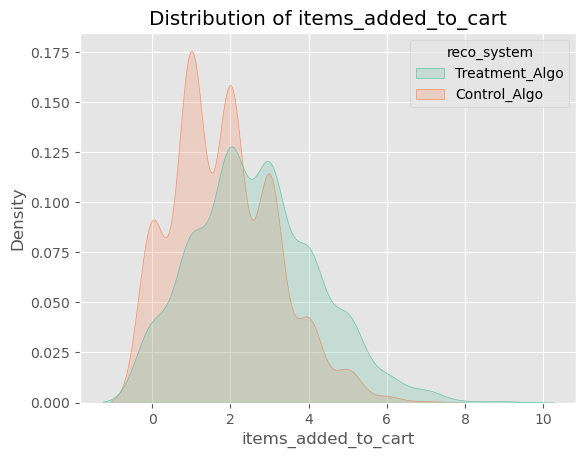

In [33]:
normal_check = pg.normality(
    data=df_reco, 
    dv='items_added_to_cart', 
    group='reco_system'
)
display(normal_check)

if normal_check.loc['Control_Algo', 'normal'] and normal_check.loc['Treatment_Algo', 'normal']:
    print('Data is Normal Distribution -> Use T-test')
else:
    print('Data is NOT Normal Distribution -> Use Mann-Whitney U or Brunner-Munzel')

sns.kdeplot(data=df_reco, x='items_added_to_cart', hue='reco_system', fill=True)
plt.title('Distribution of items_added_to_cart')
plt.show()


## 1.4 Testing (Brunner-Munzel & Bootstrap CI)

In [34]:
_, pval = brunnermunzel(control_algo, treatment_algo, alternative='less')
print(f"P-Value: {pval:.4f}")

if pval > 0.05:
    print('    -> No significant difference between the two groups')
else:
    print('    -> There is a significant difference between the two groups')
    
    sales_control = df_reco[df_reco['reco_system'] == 'Control_Algo']['sales']
    sales_treatment = df_reco[df_reco['reco_system'] == 'Treatment_Algo']['sales']
    mean_diff_val = sales_treatment.mean() - sales_control.mean()

    # Bootstrap for Confidence Interval
    data = (sales_treatment.values, sales_control.values)
    def mean_diff(x, y):
        return np.mean(x, axis=-1) - np.mean(y, axis=-1)
    
    res_boot = bootstrap(
        data=data,
        statistic=mean_diff,
        confidence_level=0.95,
        n_resamples=2000,
        random_state=1
    )

    ci_lower = res_boot.confidence_interval.low
    ci_upper = res_boot.confidence_interval.high

    print("\n=== Sales Impact Summary ===")
    print(f"The new algorithm increases average sales by: {mean_diff_val:.2f} /person")
    print(f"95% Confidence Interval (Bootstrap): Expected increase between [{ci_lower:.2f} to {ci_upper:.2f}] /person")


P-Value: 0.0000
    -> There is a significant difference between the two groups

=== Sales Impact Summary ===
The new algorithm increases average sales by: 97.12 /person
95% Confidence Interval (Bootstrap): Expected increase between [80.07 to 113.88] /person


# 2. New Button Color Testing

## 2.1 Overview Checking

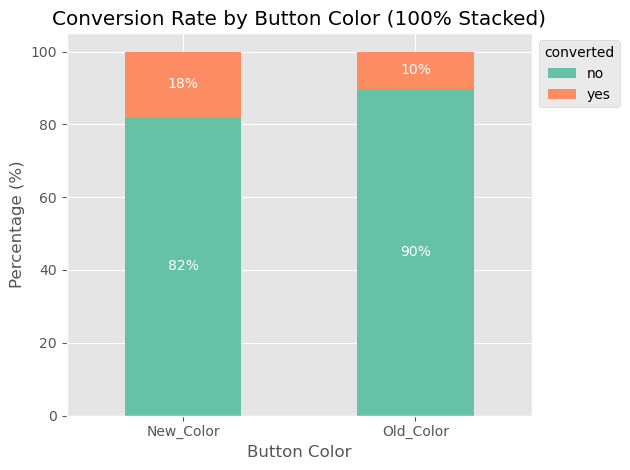

In [35]:
df_button_vis = df_button.copy()
df_button_vis['converted'] = df_button_vis['converted'].map({0:'no', 1:'yes'})

cross_tab = pd.crosstab(df_button_vis['button_color'], df_button_vis['converted'])
cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

ax = cross_tab.plot.bar(stacked=True, rot=0)
plt.ylabel('Percentage (%)')
plt.xlabel('Button Color')
plt.title('Conversion Rate by Button Color (100% Stacked)')
plt.legend(title='converted', loc='upper left', bbox_to_anchor=(1, 1))

# Add text labels on the graph
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0: # Prevent text overlap if percentage is too small
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.0f}%', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()


## 2.2 Check Power, Effect Size & Testing

In [36]:
old_color = df_button[df_button['button_color'] == 'Old_Color']
new_color = df_button[df_button['button_color'] == 'New_Color']

n_old_color = len(old_color)
n_new_color = len(new_color)
conv_old_color = old_color['converted'].sum()
conv_new_color = new_color['converted'].sum()

p_old_color = conv_old_color / n_old_color
p_new_color = conv_new_color / n_new_color

# Check Effect Size and Power
cohens_h = proportion_effectsize(p_new_color, p_old_color)
power_analysis = NormalIndPower()
ratio = n_old_color / n_new_color

power = power_analysis.solve_power(
    effect_size=cohens_h,
    nobs1=n_new_color,       
    alpha=0.05,        
    ratio=ratio,
    alternative='two-sided'
)

print(f"Effect Size (Cohen's h): {cohens_h:.4f}")
print(f"Achieved Power: {power:.4f}")

if power < 0.8:
    print('    -> Sample size might be too small. Risk of Type II Error.')
    required_n = power_analysis.solve_power(
        effect_size=cohens_h,
        power=0.8,       
        alpha=0.05,        
        ratio=ratio,
        alternative='two-sided'
    )
    print(f"Advice: To achieve a Power of 0.8, you need a sample size of about {np.ceil(required_n).astype(int)} per group")
else:
    print('    -> Good statistical power (Reliable data size)')
    
    if abs(cohens_h) >= 0.8:
        print("    -> Large Effect")
    elif abs(cohens_h) >= 0.5:
        print("    -> Medium Effect")
    else: 
        print("    -> Small Effect")

    # Hypothesis Testing (Z-Test for Proportions)
    counts = np.array([conv_new_color, conv_old_color])
    nobs = np.array([n_new_color, n_old_color])
    z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

    print('\n=== Hypothesis Testing ===')
    print(f"Z-Statistic: {z_stat:.4f}")
    print(f"P-Value:     {p_value:.4f}")

    if p_value < 0.05:
        print("    -> The conversion rates of the two buttons are significantly 'DIFFERENT'")
    else:
        print("    -> The conversion rates of the two buttons are 'NOT DIFFERENT'")


Effect Size (Cohen's h): 0.2256
Achieved Power: 0.9920
    -> Good statistical power (Reliable data size)
    -> Small Effect

=== Hypothesis Testing ===
Z-Statistic: 4.3235
P-Value:     0.0000
    -> The conversion rates of the two buttons are significantly 'DIFFERENT'


# 3. New Marketing Campaign Testing

## 3.1 Overview Checking

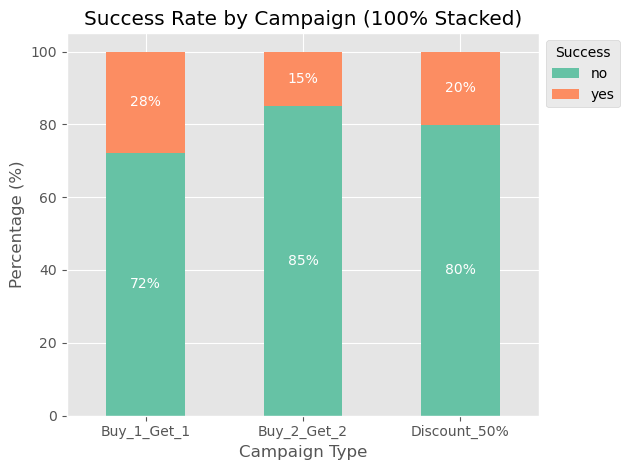

In [37]:
df_campaign_vis = df_campaign.copy()
df_campaign_vis['campaign_success'] = df_campaign_vis['campaign_success'].map({0:'no', 1:'yes'})

cross_tab = pd.crosstab(df_campaign_vis['campaign_type'], df_campaign_vis['campaign_success'])
cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

ax = cross_tab.plot.bar(stacked=True, rot=0)
plt.ylabel('Percentage (%)')
plt.xlabel('Campaign Type')
plt.title('Success Rate by Campaign (100% Stacked)')
plt.legend(title='Success', loc='upper left', bbox_to_anchor=(1, 1))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.0f}%', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()


## 3.2 Testing Flow & Post-Hoc

In [38]:
# Prepare data
obs_table = pd.crosstab(df_campaign['campaign_type'], df_campaign['campaign_success']).values

# Calculate Cramer's V
cramer_v = association(obs_table, method='cramer')
chi2_stat, p_val, dof, _ = chi2_contingency(obs_table)

# Calculate Cohen's W
n_total = len(df_campaign)
cohens_w = np.sqrt(chi2_stat / n_total)

# Check Power
power_analysis = GofChisquarePower()
actual_power = power_analysis.solve_power(
    effect_size=cohens_w,
    nobs=n_total,
    n_bins=dof + 1, 
    alpha=0.05
)

print('=== Power Analysis Results ===')
print(f"Cohen's w: {cohens_w:.4f}")
print(f"Statistical Power: {actual_power:.4f}")
print(f"Effect Size (Cramer's V): {cramer_v:.4f}")

if cramer_v >= 0.5:
    print("    -> Cramer's V Effect: Very Strong Effect")
elif cramer_v >= 0.3:
    print("    -> Cramer's V Effect: Large Effect")
elif cramer_v >= 0.1: 
    print("    -> Cramer's V Effect: Medium Effect")
else: 
    print("    -> Cramer's V Effect: Small Effect")
        
if actual_power < 0.8:
    print('    -> Power is less than 0.8 (You should collect more samples)')
    required_n = power_analysis.solve_power(
        effect_size=cohens_w,
        power=0.8,
        n_bins=(dof + 1),
        alpha=0.05
    )
    print(f"Advice: To achieve a Power of 0.8, you need a total sample size of about {np.ceil(required_n).astype(int)}")
else:
    print('    -> Good statistical power (Reliable data size)')

    if p_val > 0.05:
        print("\nConclusion: The success rates of the campaigns are 'NOT DIFFERENT' (Stop here)")
    else:
        print("\nConclusion: The success rates of the campaigns are significantly 'DIFFERENT' (Proceed to Post-Hoc)")
        print("\n=== Post-Hoc Test Results (Pairwise Comparison) ===")
        
        # Calculate Number of Successes and Total Size for each Campaign
        success_counts = df_campaign[df_campaign['campaign_success'] == 1].groupby('campaign_type').size()
        total_counts = df_campaign.groupby('campaign_type').size()
        
        campaigns_list = success_counts.index.tolist()
        pairs = list(itertools.combinations(campaigns_list, 2))
        raw_p_values = []
        
        # Z-test for proportions
        for c1, c2 in pairs:
            count = np.array([success_counts[c1], success_counts[c2]])
            nobs_arr = np.array([total_counts[c1], total_counts[c2]])
            _, pval_pair = proportions_ztest(count, nobs_arr)
            raw_p_values.append(pval_pair)
            
        # Adjust p-value with Bonferroni Correction
        reject_list, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='bonferroni')
        
        # Summary of results
        results_df = pd.DataFrame({
            'Campaign Pair': [f"{c1} vs {c2}" for c1, c2 in pairs],
            'Raw p-value': raw_p_values,
            'Corrected p-value': pvals_corrected,
            'Significant (Alpha=0.05)': reject_list
        })
        
        results_df['Raw p-value'] = results_df['Raw p-value'].round(4)
        results_df['Corrected p-value'] = results_df['Corrected p-value'].round(4)
        
        print("\nPairwise Summary Table (Bonferroni Corrected):")
        display(results_df)
        
        print("\n=== Interpretation ===")
        for index, row in results_df.iterrows():
            if row['Significant (Alpha=0.05)']:
                print(f"- Pair {row['Campaign Pair']} is significantly different")
            else:
                print(f"- Pair {row['Campaign Pair']} has no significant difference")


=== Power Analysis Results ===
Cohen's w: 0.1291
Statistical Power: 0.9965
Effect Size (Cramer's V): 0.1291
    -> Cramer's V Effect: Medium Effect
    -> Good statistical power (Reliable data size)

Conclusion: The success rates of the campaigns are significantly 'DIFFERENT' (Proceed to Post-Hoc)

=== Post-Hoc Test Results (Pairwise Comparison) ===

Pairwise Summary Table (Bonferroni Corrected):


,Campaign Pair,Raw p-value,Corrected p-value,Significant (Alpha=0.05)
0,Buy_1_Get_1 vs Buy_2_Get_2,0.0000,0.0000,True
1,Buy_1_Get_1 vs Discount_50%,0.0044,0.0133,True
2,Buy_2_Get_2 vs Discount_50%,0.0287,0.0862,False



=== Interpretation ===
- Pair Buy_1_Get_1 vs Buy_2_Get_2 is significantly different
- Pair Buy_1_Get_1 vs Discount_50% is significantly different
- Pair Buy_2_Get_2 vs Discount_50% has no significant difference
